# Import Modules

In [24]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm

In [25]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

In [26]:
BASE_DIR = "/home/umesh/Documents/Image Caption Generator"
WORKING_DIR = os.path.join(BASE_DIR, "working")

# Extract Image Features

In [27]:
# load VGG16 model
model = VGG16()

# restructure the model
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#extract features from all images

# features = {}
# directory = os.path.join(BASE_DIR, "Flickr8/Images")

# for img_name in tqdm(os.listdir(directory)):
#     img_path = os.path.join(directory, img_name)
#     image = load_img(img_path, target_size=(224, 224))
#     image = img_to_array(image)
#     image = np.expand_dims(image, axis=0)
#     image = preprocess_input(image)
#     feature = model.predict(image, verbose=0)
#     features[img_name.split(".")[0]] = feature

In [29]:
# pickle.dump(features, open(os.path.join(WORKING_DIR, "features.pkl"), "wb"))

In [30]:
#load features from pickle file
features = pickle.load(open(os.path.join(WORKING_DIR, "features.pkl"), "rb"))

In [31]:
print(features["1000268201_693b08cb0e"][0][135])

4.402392


In [32]:
#load the captions
with open(os.path.join(BASE_DIR, "Flickr8/captions.txt"), "r") as f:
    next(f)  # skip the first line
    captions_doc = f.read()

In [33]:
from collections import defaultdict

In [34]:
#create mapping of image to captions

mapping = defaultdict(list)

for line in captions_doc.split("\n"):
    if len(line) < 2:
        continue
    tokens = line.split(",")
    image_id = tokens[0]
    caption = ""
    for i in range(1, len(tokens)):
        caption += " " + tokens[i].strip()
    image_id = image_id.split(".")[0]
    mapping[image_id].append(caption)


## Preprocess Text Data

In [35]:
#preprocess the captions
def preprocess_caption(caption):
    caption = caption.lower()
    caption = caption.replace("[^A-Za-z]", "")
    caption = "<start> " + " ".join([token for token in caption.split() if len(token) > 1]) + " <end>"
    return caption


#preprocess all captions
for key, captions in mapping.items():
    for i in range(len(captions)):
        captions[i] = preprocess_caption(captions[i])

In [36]:
mapping["1000268201_693b08cb0e"]

['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
 '<start> girl going into wooden building <end>',
 '<start> little girl climbing into wooden playhouse <end>',
 '<start> little girl climbing the stairs to her playhouse <end>',
 '<start> little girl in pink dress going into wooden cabin <end>']

In [37]:
#tokenize the captions
all_captions = []
for key in mapping.keys():
    for caption in mapping[key]:
        all_captions.append(caption)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8483


In [38]:
#get max length of captions useful for padding later
max_length = max(len(caption.split()) for caption in all_captions)
print("Maximum Caption Length:", max_length)

Maximum Caption Length: 35


## Train Test Split

In [39]:
image_ids = list(mapping.keys())
split = int(0.9 * len(image_ids))
train_image_ids = image_ids[:split]
test_image_ids = image_ids[split:]

In [40]:
# create data generator to get data in batches for training (to avoid memory issues)

def data_generator(image_ids, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    while True:
        for i in range(0, len(image_ids), batch_size):
            X1, X2, y = [], [], []
            for image_id in image_ids[i:i+batch_size]:
                captions = mapping[image_id]
                feature = features[image_id][0]
                for caption in captions:
                    seq = tokenizer.texts_to_sequences([caption])[0]
                    for j in range(1, len(seq)):
                        in_seq, out_seq = seq[:j], seq[j]
                        in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                        out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                        X1.append(feature)
                        X2.append(in_seq)
                        y.append(out_seq)
            yield (np.array(X1), np.array(X2)), np.array(y)

## Model Creation

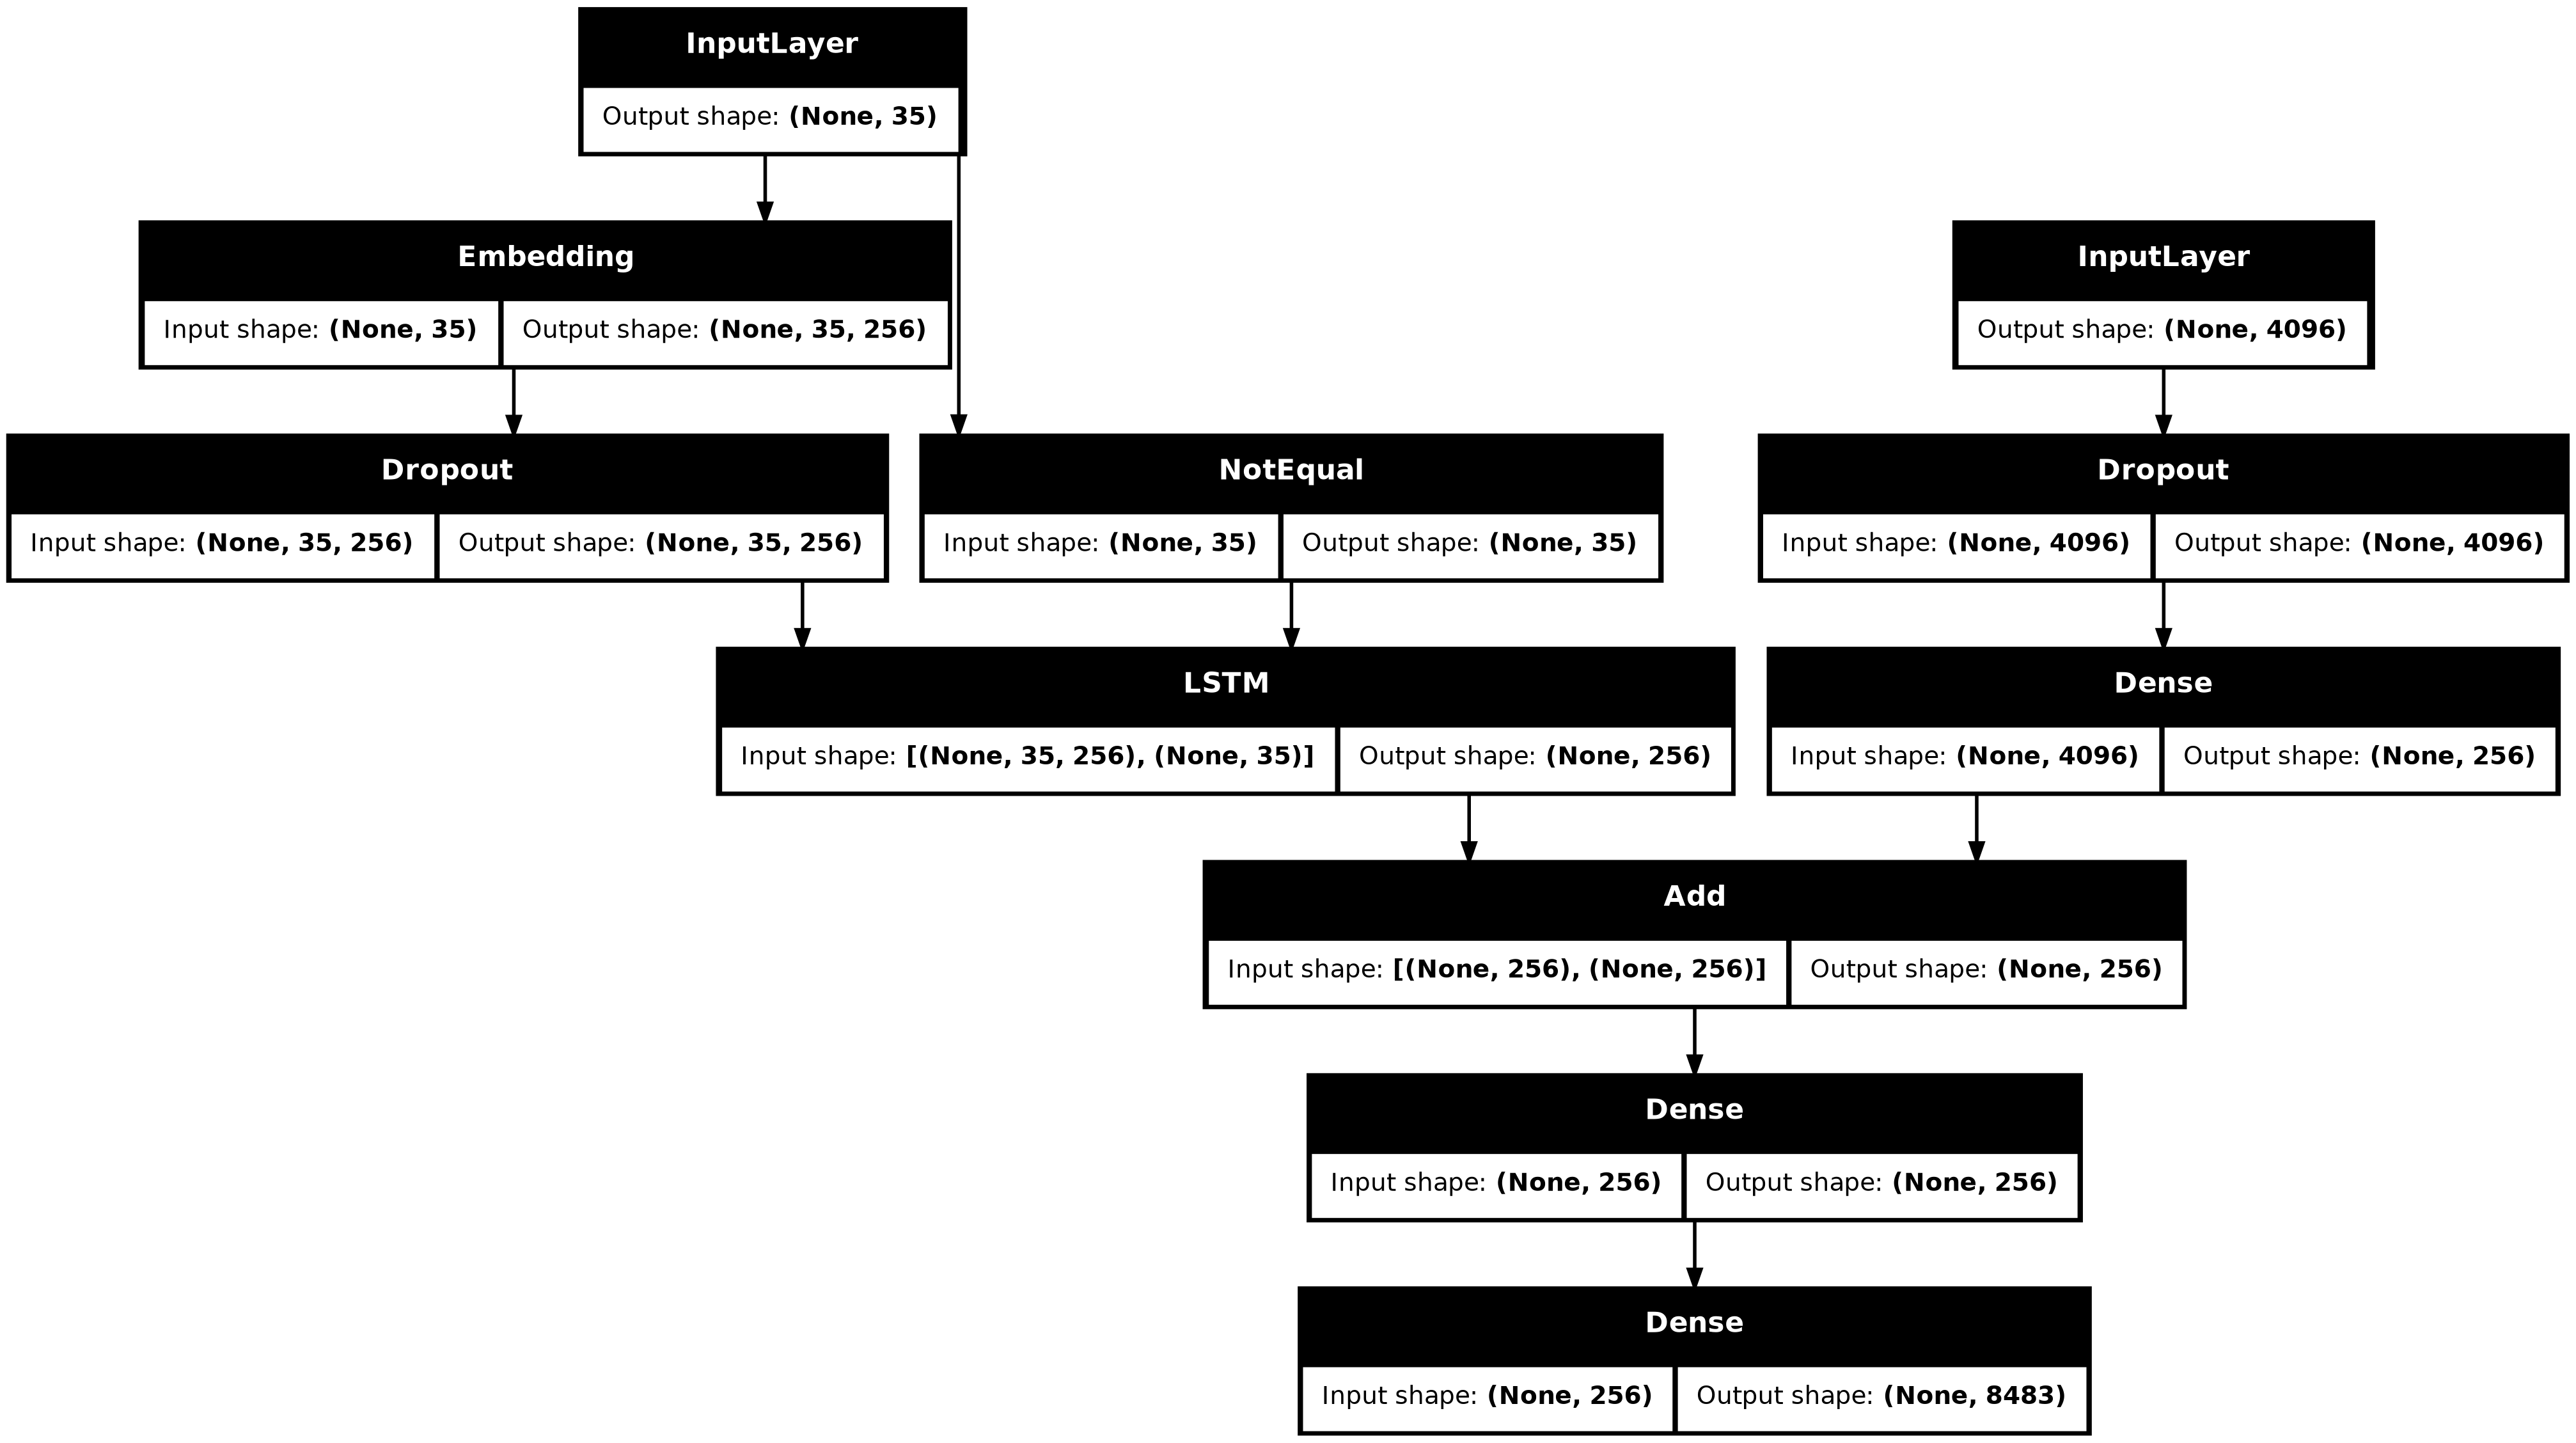

In [41]:
# Encoder Model

#image feature extractor model
input1 = Input(shape=(4096,))
fe1 = Dropout(0.5)(input1)
fe2 = Dense(256, activation="relu")(fe1)

# input for captions
input2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(input2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)



# decoder model

decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation="relu")(decoder1)
outputs = Dense(vocab_size, activation="softmax")(decoder2)


model = Model(inputs=[input1, input2], outputs=outputs)
model.compile(loss="categorical_crossentropy", optimizer="adam")

#plot the model architecture
plot_model(model, to_file=os.path.join(WORKING_DIR, "model.png"), show_shapes=True)

In [42]:
# train the model

epochs = 15
batch_size = 64
steps = len(train_image_ids) // batch_size

for i in range(epochs):
    generator = data_generator(train_image_ids, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    model.fit(generator, epochs=1, steps_per_epoch=steps,verbose=1)

model.save(os.path.join(WORKING_DIR, "best_model.h5"))

  2/113 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 8.9578   

2026-06-07 01:42:59.743388: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - loss: 5.5842
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 4.3488
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - loss: 3.7710
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 3.4787
  2/113 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 3.2343  

2026-06-07 01:43:52.960908: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 288269408 bytes after encountering the first element of size 288269408 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - loss: 3.2712
  2/113 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 3.0840  

...

113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 130ms/step - loss: 3.1112
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - loss: 2.9878
  2/113 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 2.8676  

2026-06-07 01:44:37.615020: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 288269408 bytes after encountering the first element of size 288269408 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - loss: 2.8887
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 2.8041
  2/113 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 2.6760  

2026-06-07 01:45:07.799052: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 288269408 bytes after encountering the first element of size 288269408 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 2.7288
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - loss: 2.6611
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - loss: 2.6060
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - loss: 2.5576
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - loss: 2.5166
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - loss: 2.4763


# Generate captions for test images

In [43]:

def ind_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

In [51]:
#generate caption for an image
def generate_caption(model, tokenizer, photo, max_length):
    in_text = "<start>"
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = ind_to_word(yhat, tokenizer)
        if word is None:
            break
        in_text += " " + word
        if word == "end":
            break
    return in_text

In [52]:
# validate the model on test images
actual, predicted = [], []
for image_id in range(len(test_image_ids[:5])):
    captions = mapping[test_image_ids[image_id]]
    feature = features[test_image_ids[image_id]][0].reshape(1, 4096)
    y_pred = generate_caption(model, tokenizer, feature, max_length)
    predicted.append(y_pred)
    actual.append(captions)

In [53]:
actual[1], predicted[1]

(['<start> brown doberman is outside with stick in its mouth <end>',
  '<start> brown dog shows his teeth <end>',
  '<start> dog bites stick <end>',
  '<start> dog is biting twig <end>',
  '<start> dog with sharp teeth is chewing on stick outside <end>'],
 '<start> brown dog is digging in the air end')